# 23CSE463 – Quantum Computing
## Worksheet 7: Implementation of Grover\'s Search Algorithm Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 7

**Aim:** To implement Grover\'s search algorithm in Qiskit for two and three qubits, to construct the oracle and the diffusion operator, and to study how the probability of finding the marked item changes with the number of iterations.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


REG_NO = "CH.SC.U4CSE24102"

def mcz(qc, n):
    """multi-controlled Z on all n qubits (CZ for n = 2)"""
    if n == 2:
        qc.cz(0, 1)
    else:
        qc.h(n - 1); qc.mcx(list(range(n - 1)), n - 1); qc.h(n - 1)

def oracle(marked, n):
    """phase oracle: -1 on each marked bit string (rightmost character = qubit 0)"""
    if isinstance(marked, str):
        marked = [marked]
    o = QuantumCircuit(n, name="Oracle")
    for w in marked:
        zeros = [i for i, b in enumerate(reversed(w)) if b == "0"]
        if zeros: o.x(zeros)
        mcz(o, n)
        if zeros: o.x(zeros)
    return o

def diffuser(n):
    d = QuantumCircuit(n, name="Diffuser")
    d.h(range(n)); d.x(range(n))
    mcz(d, n)
    d.x(range(n)); d.h(range(n))
    return d

def grover(marked, n, k, measure=True):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for _ in range(k):
        qc.barrier(); qc.compose(oracle(marked, n), inplace=True)
        qc.barrier(); qc.compose(diffuser(n), inplace=True)
    if measure:
        qc.measure_all()
    return qc

def p_success(marked, n, k):
    if isinstance(marked, str): marked = [marked]
    probs = Statevector(grover(marked, n, k, measure=False)).probabilities_dict()
    return sum(probs.get(w, 0) for w in marked)


Qiskit version: 2.5.2


### Program 1
Create the equal superposition of two qubits. Display the four amplitudes and probabilities.

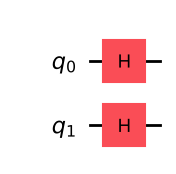

  |00> : +0.500+0.000j   P = 0.250
  |01> : +0.500+0.000j   P = 0.250
  |10> : +0.500+0.000j   P = 0.250
  |11> : +0.500+0.000j   P = 0.250


In [2]:
# Program 1: equal superposition of two qubits
qc = QuantumCircuit(2)
qc.h([0, 1])
show(qc.draw("mpl"))
amps(Statevector(qc))

**Inference:** H on both qubits gives |s> = ½(|00>+|01>+|10>+|11>): all four amplitudes are 1/√4 = 0.5 and every item has probability 0.25.

### Program 2
Add the oracle that marks 11 (a CZ gate). Display the statevector and show that the sign of the marked item has changed while the probabilities have not.

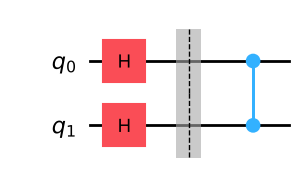

  |00> : +0.500+0.000j   P = 0.250
  |01> : +0.500+0.000j   P = 0.250
  |10> : +0.500+0.000j   P = 0.250
  |11> : -0.500+0.000j   P = 0.250
Probabilities unchanged: True


In [3]:
# Program 2: oracle marking 11 (CZ)
qc = QuantumCircuit(2)
qc.h([0, 1]); qc.barrier()
qc.cz(0, 1)
show(qc.draw("mpl"))
sv2 = Statevector(qc)
amps(sv2)
print("Probabilities unchanged:", np.allclose(sv2.probabilities(), [0.25] * 4))

**Inference:** After the CZ oracle the amplitude of |11> becomes −0.5 while the others stay +0.5. The probabilities are still all 0.25, because the sign disappears when the amplitude is squared — the oracle only marks the item in the phase.

### Program 3
Build the oracles that mark 00, 01 and 10 using X gates before and after the CZ gate. Verify each by displaying the diagonal of its operator.

Oracle for 00: diagonal {'00': -1, '01': 1, '10': 1, '11': 1}
Oracle for 01: diagonal {'00': 1, '01': -1, '10': 1, '11': 1}
Oracle for 10: diagonal {'00': 1, '01': 1, '10': -1, '11': 1}
Oracle for 11: diagonal {'00': 1, '01': 1, '10': 1, '11': -1}


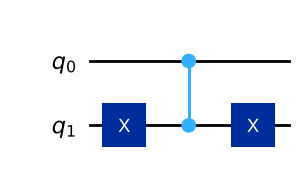

In [4]:
# Program 3: oracles for 00, 01, 10 (X before and after CZ)
for w in ["00", "01", "10", "11"]:
    o = oracle(w, 2)
    diag = np.real(np.diag(Operator(o).data))
    print(f"Oracle for {w}: diagonal", {f"{i:02b}": int(d) for i, d in enumerate(diag)})
show(oracle("01", 2).draw("mpl"))

**Inference:** Each oracle is diagonal with −1 exactly at its marked item and +1 elsewhere: the X gates map the marked string to 11, the CZ flips its sign, and the second X gates undo the mapping. (Diagonal index labels use Qiskit order q1q0.)

### Program 4
Build the two-qubit diffuser from H, X and CZ gates. Apply it to the state from Program 2 and display the amplitudes after it.

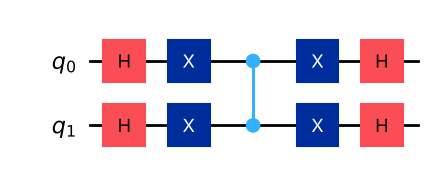

  |11> : -1.000+0.000j   P = 1.000


In [5]:
# Program 4: two-qubit diffuser applied to the state from Program 2
d = diffuser(2)
show(d.draw("mpl"))
qc = QuantumCircuit(2); qc.h([0, 1]); qc.cz(0, 1)
qc.compose(d, inplace=True)
amps(Statevector(qc))

**Inference:** After the diffuser the state is −|11>: amplitudes 0, 0, 0 and −1. The mean of (½, ½, ½, −½) is ¼, so the unmarked amplitudes become 2·¼ − ½ = 0 and the marked one 2·¼ + ½ = 1. The overall −1 is the global phase of the H-X-CZ-X-H circuit (= −D) and does not affect measurement.

### Program 5
Assemble the complete two-qubit Grover circuit for the marked item 11. Run it with 1024 shots and plot the histogram.

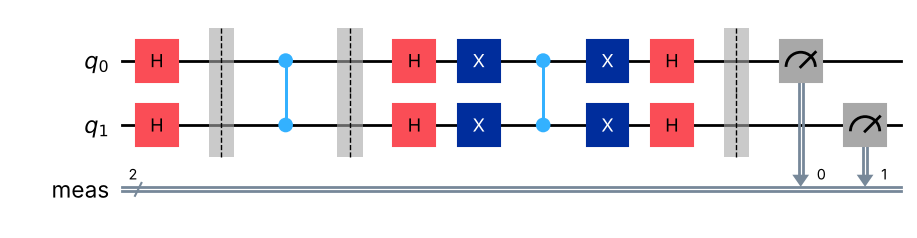

Counts: {'11': 1024}


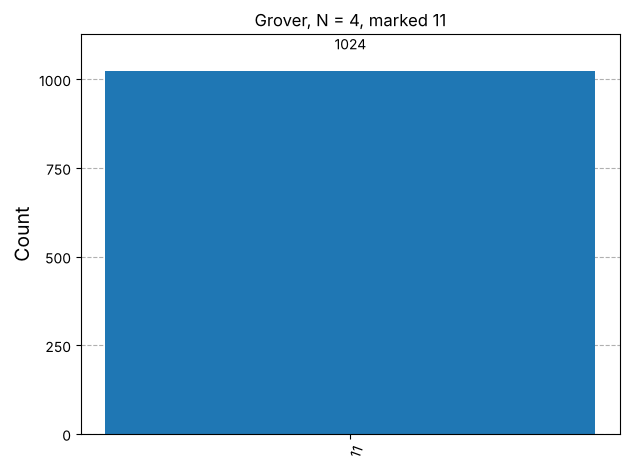

In [6]:
# Program 5: complete two-qubit Grover search for 11
qc = grover("11", 2, 1)
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
show(plot_histogram(counts, title="Grover, N = 4, marked 11"))

**Inference:** All 1024 shots return 11: for N = 4 a single oracle + diffuser iteration finds the marked item with certainty, versus 2.25 queries on average classically.

### Program 6
Run the two-qubit Grover circuit for each of the four possible marked items and tabulate the marked item against the measured result.

In [7]:
# Program 6: every marked item, N = 4
print("Marked item | Measured (1024 shots)")
for w in ["00", "01", "10", "11"]:
    c = run(grover(w, 2, 1))
    print(f"     {w}     | {c}   {'OK' if list(c) == [w] else ''}")

Marked item | Measured (1024 shots)


     00     | {'00': 1024}   OK


     01     | {'01': 1024}   OK


     10     | {'10': 1024}   OK


     11     | {'11': 1024}   OK


**Inference:** For each of the four possible marked items the measured result equals the marked item in 100% of the shots, confirming that one Grover iteration solves any N = 4 search.

### Program 7
Implement three-qubit Grover search for the marked item 101. Record the probability of success after one and after two iterations and compare it with the formula in the theory.

theta = 20.70 deg


k = 1: P(101) simulated = 0.820, exact = 0.7812, formula sin^2((2k+1)theta) = 0.7812


k = 2: P(101) simulated = 0.952, exact = 0.9453, formula sin^2((2k+1)theta) = 0.9453


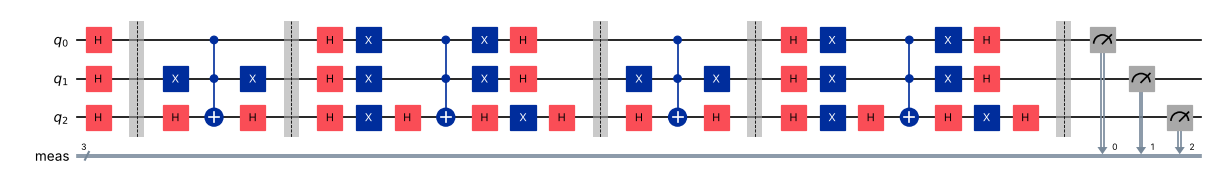

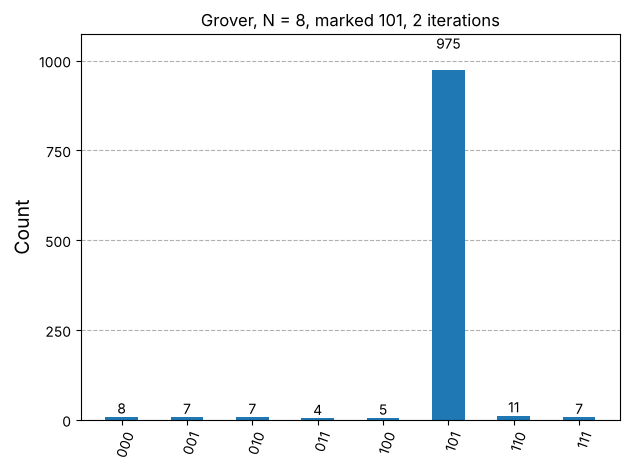

In [8]:
# Program 7: three-qubit Grover for 101, 1 and 2 iterations
theta = np.arcsin(1 / np.sqrt(8))
print(f"theta = {np.degrees(theta):.2f} deg")
for k in [1, 2]:
    qc = grover("101", 3, k)
    c = run(qc)
    p_exact = p_success("101", 3, k)
    print(f"k = {k}: P(101) simulated = {c.get('101',0)/1024:.3f}, exact = {p_exact:.4f}, "
          f"formula sin^2((2k+1)theta) = {np.sin((2*k+1)*theta)**2:.4f}")
    if k == 2:
        show(qc.draw("mpl", fold=-1, scale=0.6))
        show(plot_histogram(c, title="Grover, N = 8, marked 101, 2 iterations"))

**Inference:** With θ = 20.7°, the success probability is 78.1% after one iteration and 94.5% after two, both from the statevector and the formula sin²((2k+1)θ); the 1024-shot results agree closely (small differences come from the finite number of shots). Two iterations ≈ (π/4)√8 = 2.2 is the best choice for N = 8.

### Program 8
For the three-qubit search, vary the number of iterations from 0 to 6 and plot the probability of success against the number of iterations. Identify the best number of iterations and explain the drop that follows it.

k = 0:  simulated 0.121   formula 0.125
k = 1:  simulated 0.792   formula 0.781
k = 2:  simulated 0.932   formula 0.945
k = 3:  simulated 0.353   formula 0.330
k = 4:  simulated 0.012   formula 0.012
k = 5:  simulated 0.536   formula 0.548
k = 6:  simulated 1.000   formula 1.000


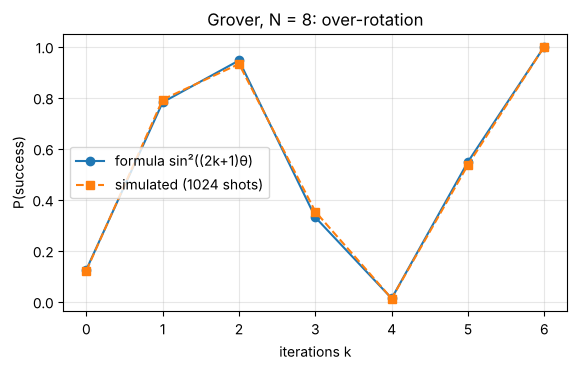

Best number of iterations (first maximum, fewest oracle calls): 2


In [9]:
# Program 8: success probability vs number of iterations (k = 0..6)
ks = range(7)
p_sim = [run(grover("101", 3, k)).get("101", 0) / 1024 for k in ks]
p_th = [np.sin((2 * k + 1) * theta) ** 2 for k in ks]
for k in ks:
    print(f"k = {k}:  simulated {p_sim[k]:.3f}   formula {p_th[k]:.3f}")
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(ks, p_th, "o-", label="formula sin²((2k+1)θ)")
ax.plot(ks, p_sim, "s--", label="simulated (1024 shots)")
ax.set_xlabel("iterations k"); ax.set_ylabel("P(success)"); ax.set_title("Grover, N = 8: over-rotation")
ax.grid(alpha=.3); ax.legend(); show(fig)
first_peak = next(k for k in ks if p_th[k + 1] < p_th[k])
print("Best number of iterations (first maximum, fewest oracle calls):", first_peak)

**Inference:** The probability rises 0.125 → 0.781 → 0.945 for k = 0, 1, 2, then falls to 0.330 at k = 3 and 0.012 at k = 4, before rising again (0.548 at k = 5, ≈1.0 at k = 6, since P_k is periodic in k). The best choice is k = 2: it is the first maximum and needs the fewest oracle calls (k = 6 costs three times as many queries for almost no gain). Each iteration rotates the state by 2θ ≈ 41° towards |w>; after passing it the state rotates away again (over-rotation).

### Program 9
Mark two items (101 and 110) in the three-qubit search. Show that one iteration is enough, and explain the result using the formula for M marked items.

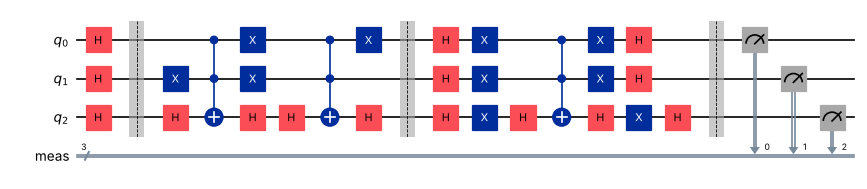

Counts after 1 iteration: {'101': 513, '110': 511}
theta = 30.0 deg;  P after 1 iteration = sin^2(3 theta) = 1.000
Exact success probability: 1.0


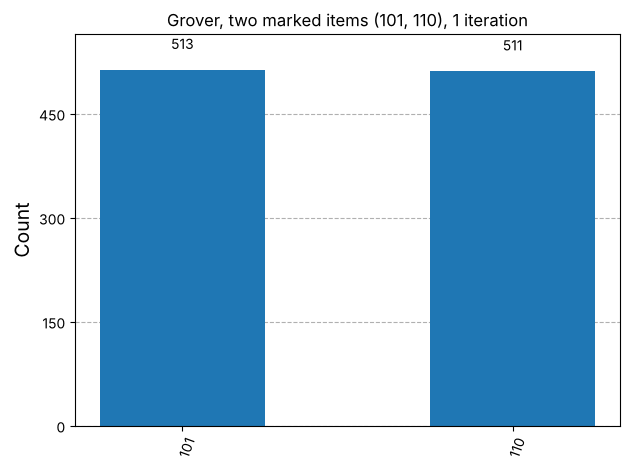

In [10]:
# Program 9: two marked items 101 and 110, N = 8
M, Nn = 2, 8
th2 = np.arcsin(np.sqrt(M / Nn))
qc = grover(["101", "110"], 3, 1)
show(qc.draw("mpl", fold=-1, scale=0.6))
c = run(qc)
print("Counts after 1 iteration:", c)
print(f"theta = {np.degrees(th2):.1f} deg;  P after 1 iteration = sin^2(3 theta) = {np.sin(3*th2)**2:.3f}")
print("Exact success probability:", round(p_success(["101", "110"], 3, 1), 4))
show(plot_histogram(c, title="Grover, two marked items (101, 110), 1 iteration"))

**Inference:** After one iteration only 101 and 110 appear (≈50% each, 100% in total). With M = 2, sinθ = √(2/8) = ½, θ = 30°, so P₁ = sin²(3·30°) = sin²(90°) = 1: more marked items mean a larger θ and fewer iterations (k_opt ≈ (π/4)√(N/M)).

### Program 10
Take the last digit of your register number, find the remainder on division by 8 and write it as a three-bit string. Use it as the marked item in the three-qubit search and report the histogram for the best number of iterations.

Register number CH.SC.U4CSE24102: last digit = 2, 2 mod 8 = 2  ->  marked item 010
Best number of iterations: 2


Counts: {'001': 6, '110': 11, '011': 1, '111': 7, '100': 10, '101': 6, '000': 8, '010': 975}   P(010) = 0.952


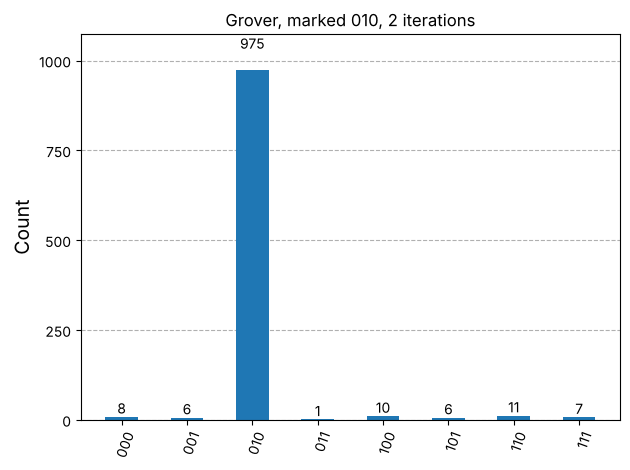

In [11]:
# Program 10: marked item from the register number
last = int(REG_NO[-1])
w = format(last % 8, "03b")
print(f"Register number {REG_NO}: last digit = {last}, {last} mod 8 = {last % 8}  ->  marked item {w}")
k_best = int(np.floor(np.pi / 4 * np.sqrt(8)))
print("Best number of iterations:", k_best)
qc = grover(w, 3, k_best)
c = run(qc)
print("Counts:", c, f"  P({w}) = {c.get(w,0)/1024:.3f}")
show(plot_histogram(c, title=f"Grover, marked {w}, {k_best} iterations"))

**Inference:** For CH.SC.U4CSE24102 the last digit is 2, 2 mod 8 = 2, so the marked item is 010. With the best k = 2 iterations, 010 is measured in about 95% of the shots (theory 94.5%), far above every other outcome (≈1% each).

## Viva Q&A

**1. What problem does Grover\'s algorithm solve?**  
It searches an unstructured (unsorted) database of N = 2ⁿ items for an item marked by an oracle, i.e. finds w with f(w) = 1, using about (π/4)√N oracle queries.

**2. How many steps does a classical search need for N items, and how many does Grover\'s algorithm need?**  
Classically about N/2 queries on average (N in the worst case); Grover's algorithm needs about (π/4)√N iterations, e.g. 2 instead of ~4 for N = 8.

**3. What does the oracle do to the marked item?**  
It multiplies the amplitude of the marked item by −1 (U_w = I − 2|w><w|) and leaves every other amplitude unchanged.

**4. Why do the measurement probabilities not change immediately after the oracle?**  
The oracle only changes the sign (phase) of the marked amplitude; the probability is the squared magnitude, which does not depend on the sign. The diffuser is needed to turn this phase difference into an amplitude difference.

**5. What does the diffuser do? What is meant by inversion about the mean?**  
The diffuser D = 2|s><s| − I reflects every amplitude about the average: new = 2·mean − old. Because the marked amplitude is negative it lies far below the mean, so after the inversion it ends up far above it, while the others shrink — this is inversion about the mean.

**6. What is the best number of iterations for N = 4 and for N = 8?**  
For N = 4, k = 1 (success probability 100%). For N = 8, k = 2 (≈94.5%), from k_opt ≈ (π/4)√N.

**7. What happens if the oracle and the diffuser are repeated too many times?**  
The state rotates past the marked state (over-rotation), so the success probability decreases again (e.g. 94.5% → 33% → 1% for N = 8). P_k = sin²((2k+1)θ) is periodic in k.

**8. Is the speed-up of Grover\'s algorithm quadratic or exponential?**  
Quadratic: O(√N) versus O(N). It is provably optimal for unstructured search, so no exponential speed-up is possible for this problem.

**9. How does the number of marked items change the number of iterations needed?**  
With M marked items, sinθ = √(M/N), so θ is larger and the optimal number of iterations k ≈ (π/4)√(N/M) is smaller; e.g. M = 2, N = 8 needs only one iteration.

**10. What is the effect of Grover\'s algorithm on symmetric-key cryptography?**  
Grover's search reduces brute-force key search from 2ⁿ to about 2^(n/2) operations, effectively halving the key length (AES-128 → 64-bit security). The countermeasure is to double the key length (e.g. use AES-256).

## Result

Grover's search algorithm was implemented in Qiskit for two and three qubits with phase oracles (CZ / multi-controlled Z with X gates) and the H-X-MCZ-X-H diffuser. For N = 4 one iteration found every marked item with 100% probability. For N = 8 (marked 101) the success probability was 78.1% after one and 94.5% after two iterations, matching sin²((2k+1)θ), and over-rotation was observed beyond k = 2. With two marked items one iteration sufficed, and the register-number item 010 was found with ≈94.5% probability. Hence the experiment was successfully completed.